In [1]:
# auto-reload edited modules without restarting kernel
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

# default figure size: (10, 4); for larger plots use (12, 4)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)

# 1. Data Loading

## 1.1 Fetch stock data

In [2]:
from src.data import TICKER_DEFAULT, fetch_stock

stocks = {TICKER_DEFAULT: fetch_stock(TICKER_DEFAULT)}
print(TICKER_DEFAULT, stocks[TICKER_DEFAULT].shape,
      "from", stocks[TICKER_DEFAULT].index.min().date(),
      "to",   stocks[TICKER_DEFAULT].index.max().date())

AAPL (2861, 6) from 2015-01-02 to 2026-05-19


In [3]:
from src.data import fetch_macro

macro = fetch_macro()
print("Macro shape:", macro.shape)
print(macro.tail())

Macro shape: (2866, 6)
                  VIX          SPX        DXY    TNX         OIL         GOLD
Date                                                                         
2026-05-14  17.260000  7501.240234  98.879997  4.461  101.169998  4678.100098
2026-05-15  18.430000  7408.500000  99.269997  4.595  105.419998  4555.799805
2026-05-18  17.820000  7403.049805  98.970001  4.623  108.660004  4552.500000
2026-05-19  18.059999  7353.609863  99.300003  4.667  107.769997  4506.299805
2026-05-20  18.110001  7353.609863  99.445000  4.667  102.919998  4486.000000


In [4]:
from src.data import build_dataset

dataset = build_dataset(TICKER_DEFAULT, stocks, macro)
print("Dataset shape:", dataset.shape)
print("Columns:", list(dataset.columns))
dataset.head()

Dataset shape: (2861, 12)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD']


,Open,High,Low,Close,Volume,Ticker,VIX,SPX,DXY,TNX,OIL,GOLD
Date,,,,,,,,,,,,
2015-01-02,24.648443,24.659508,23.754470,24.192606,212818400,AAPL,17.790001,2058.199951,91.080002,2.123,52.689999,1186.000000
2015-01-05,23.962469,24.042131,23.325182,23.511057,257142000,AAPL,19.920000,2020.579956,91.379997,2.039,50.040001,1203.900024
2015-01-06,23.575235,23.772175,23.152589,23.513277,263188400,AAPL,21.120001,2002.609985,91.500000,1.963,47.930000,1219.300049
2015-01-07,23.721278,23.942559,23.610638,23.842983,160423600,AAPL,19.309999,2025.900024,91.889999,1.954,48.650002,1210.599976
2015-01-08,24.170472,24.816610,24.053192,24.759077,237458000,AAPL,17.010000,2062.139893,92.370003,2.016,48.790001,1208.400024


# 2. EDA & Pre-processing

## 2.1 Dataset Overview

In [5]:
df = dataset.copy()
df["LogVolume"] = np.log1p(df["Volume"]) # Volume is heavy right-tail

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nDate range:", df.index.min().date(), "->", df.index.max().date())

Shape: (2861, 13)

Dtypes:
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Ticker           str
VIX          float64
SPX          float64
DXY          float64
TNX          float64
OIL          float64
GOLD         float64
LogVolume    float64
dtype: object

Date range: 2015-01-02 -> 2026-05-19


## 2.2 Missing Values

In [8]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing": missing_count, "pct(%)": missing_pct})
print(missing_table)

df = df.dropna()
print("After dropna:", df.shape)

           missing  pct(%)
Open             0     0.0
High             0     0.0
Low              0     0.0
Close            0     0.0
Volume           0     0.0
Ticker           0     0.0
VIX              0     0.0
SPX              0     0.0
DXY              0     0.0
TNX              0     0.0
OIL              0     0.0
GOLD             0     0.0
LogVolume        0     0.0
After dropna: (2861, 13)


## 2.3 Duplicates

In [9]:
print("Duplicated rows:",  df.duplicated().sum())
print("Duplicated index:", df.index.duplicated().sum())

df = df[~df.index.duplicated(keep="first")]

Duplicated rows: 0
Duplicated index: 0


## 2.4 Outliers (IQR rule, k=1.5)

Close       :    0 outliers (0.0%)  bounds=[-164.54, 373.46]
Volume      :  139 outliers (4.9%)  bounds=[-47906100.00, 245029100.00]
LogVolume   :   11 outliers (0.4%)  bounds=[16.77, 19.89]


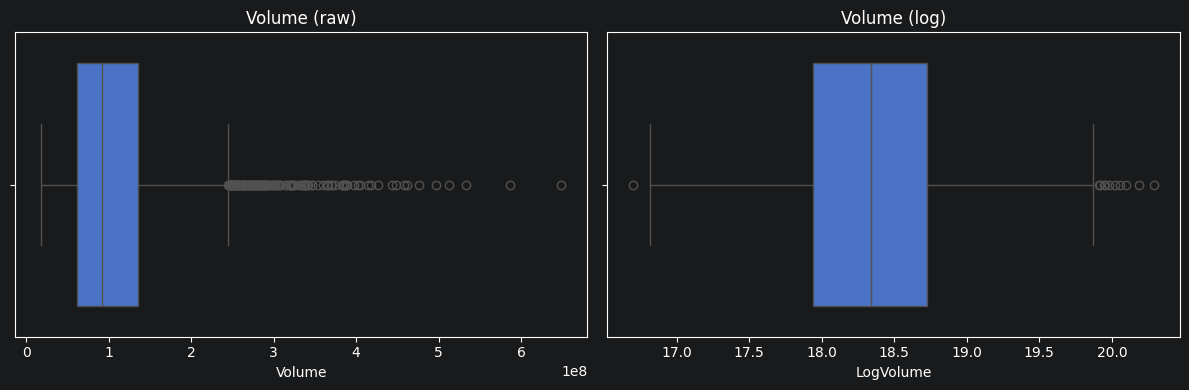

In [10]:
def iqr_outliers(series: pd.Series, k: float = 1.5):
    """Outlier if outside [Q1 - k*IQR, Q3 + k*IQR]."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - k * IQR, Q3 + k * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

for col in ["Close", "Volume", "LogVolume"]:
    mask, lo, hi = iqr_outliers(df[col])
    print(f"{col:12s}: {mask.sum():4d} outliers ({mask.mean()*100:.1f}%)  "
          f"bounds=[{lo:.2f}, {hi:.2f}]")

# boxplot before/after log on Volume
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Volume"],     ax=axes[0]); axes[0].set_title("Volume (raw)")
sns.boxplot(x=df["LogVolume"],  ax=axes[1]); axes[1].set_title("Volume (log)")
plt.tight_layout()
plt.show()

## 2.5 Uniqueness check

In [12]:
print(df.nunique().sort_values())

Ticker          1
DXY          1403
VIX          1484
TNX          1914
OIL          2287
GOLD         2477
Close        2823
SPX          2849
LogVolume    2854
Volume       2854
Low          2861
Open         2861
High         2861
dtype: int64


## 2.6 Descriptive Statistics

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
desc.round(2)

,count,mean,median,std,min,25%,50%,75%,max
Open,2861.0,1.113100e+02,110.71,78.27,20.49,37.19,110.71,1.715700e+02,3.002400e+02
High,2861.0,1.125200e+02,112.12,79.11,20.87,37.47,112.12,1.732500e+02,3.032000e+02
Low,2861.0,1.102000e+02,108.98,77.52,20.37,36.81,108.98,1.703400e+02,2.965200e+02
Close,2861.0,1.114100e+02,110.62,78.35,20.57,37.21,110.62,1.717100e+02,3.002300e+02
Volume,2861.0,1.092649e+08,92186800.00,67941777.86,17910600.00,61944600.00,92186800.00,1.351784e+08,6.488252e+08
VIX,2861.0,1.839000e+01,16.69,7.05,9.14,13.63,16.69,2.125000e+01,8.269000e+01
SPX,2861.0,3.724570e+03,3373.94,1433.92,1829.08,2531.94,3373.94,4.521540e+03,7.501240e+03
DXY,2861.0,9.832000e+01,97.66,4.79,88.59,94.87,97.66,1.016400e+02,1.141100e+02
TNX,2861.0,2.690000e+00,2.43,1.15,0.50,1.78,2.43,3.870000e+00,4.990000e+00
OIL,2861.0,6.290000e+01,61.68,17.75,-37.63,49.80,61.68,7.371000e+01,1.237000e+02


## 2.7 Univariate, Bivariate, Multivariate analysis

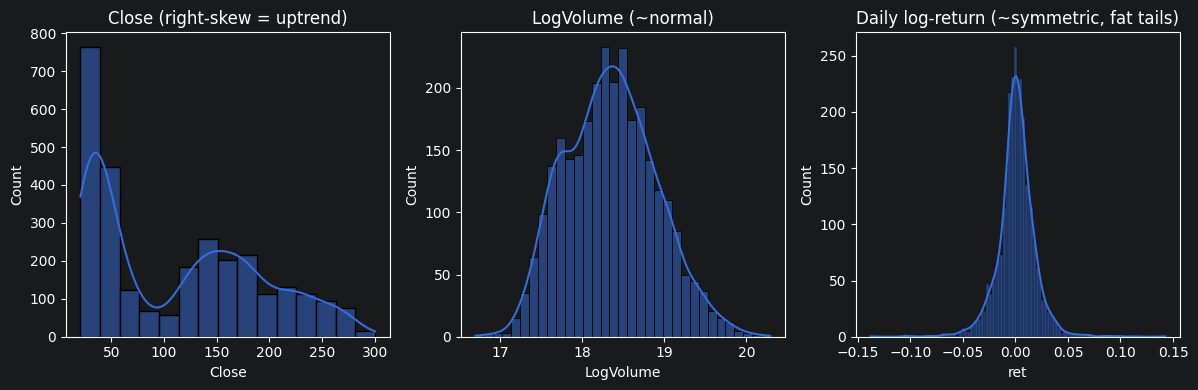

In [14]:
# temporary log-return for analysis (re-defined properly in features.py)
df["ret"] = np.log(df["Close"] / df["Close"].shift(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(df["Close"],     kde=True, ax=axes[0]); axes[0].set_title("Close (right-skew = uptrend)")
sns.histplot(df["LogVolume"], kde=True, ax=axes[1]); axes[1].set_title("LogVolume (~normal)")
sns.histplot(df["ret"].dropna(), kde=True, ax=axes[2]); axes[2].set_title("Daily log-return (~symmetric, fat tails)")
plt.tight_layout(); plt.show()

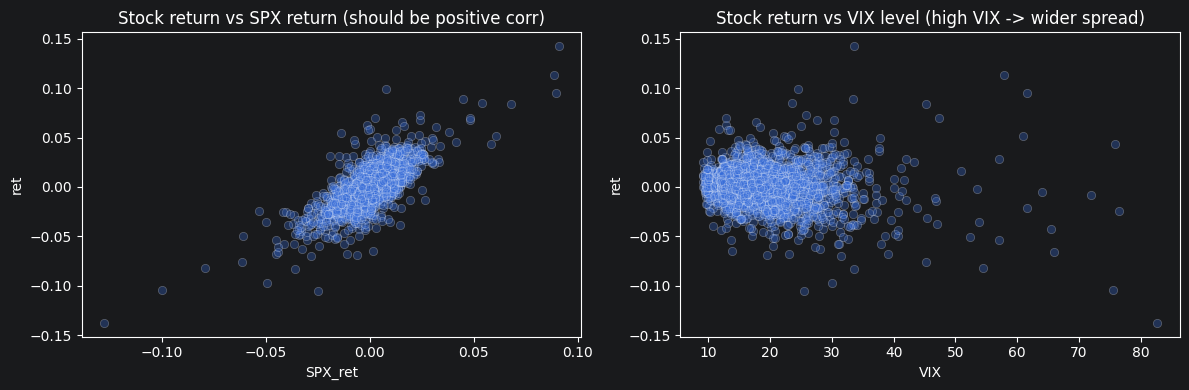

In [15]:
df["SPX_ret"] = np.log(df["SPX"] / df["SPX"].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x=df["SPX_ret"], y=df["ret"], ax=axes[0], alpha=0.3)
axes[0].set_title("Stock return vs SPX return (should be positive corr)")
sns.scatterplot(x=df["VIX"], y=df["ret"], ax=axes[1], alpha=0.3)
axes[1].set_title("Stock return vs VIX level (high VIX -> wider spread)")
plt.tight_layout(); plt.show()

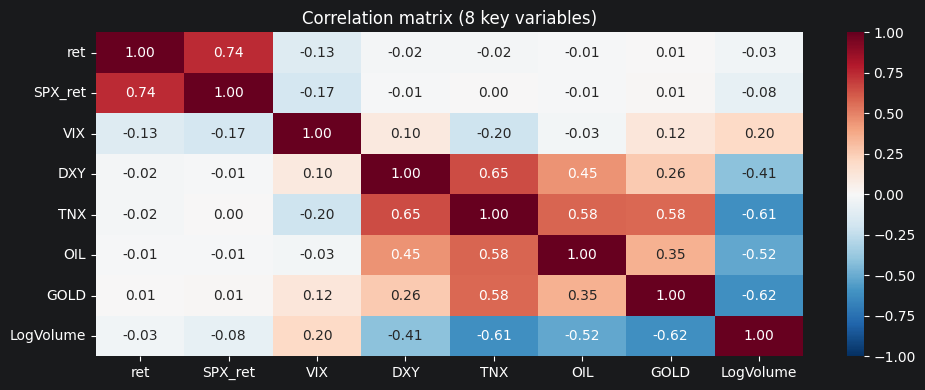

In [16]:
corr_cols = ["ret", "SPX_ret", "VIX", "DXY", "TNX", "OIL", "GOLD", "LogVolume"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (8 key variables)")
plt.tight_layout(); plt.show()

## 2.8 Conclusion & Strategy

**Findings**:
1. Data is clean no missing after merge, no duplicates.
2. Close shows uptrend (non-stationary) → MUST predict returns, not prices.
3. Volume is right-skewed → use log(1+Volume) everywhere.
4. Daily returns are ~symmetric but have fat tails → robust to outliers, winsorize target at 3ơ.
5. SPX/VIX correlate strongly with stock return → keep all 6 macros as features.

**Decisions for next phase**:
- Target = log-return at horizon h=5 (1 trading week).
- Features = technical (lag, MA, RSI, MACD, Bollinger, microstructure)
  + macro (VIX/SPX/DXY/TNX/OIL/GOLD)
  + calendar (day-of-week, month).
- Split 70/15/15 time-aware, no shuffle.
- Models: NaiveZero + AlwaysLong baselines + LinearRegression + RandomForest.
- Hyperparameter tune RF on held-out val set.
- Evaluate by IC + DirAcc + walk-forward Sharpe.

# 3. Feature Engineering

In [17]:
from src.features import build_training_set

feat_df = build_training_set(TICKER_DEFAULT, stocks, macro)
print("Feature df shape:", feat_df.shape)
print("Columns:", list(feat_df.columns))

Feature df shape: (2793, 60)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'VIX', 'SPX', 'DXY', 'TNX', 'OIL', 'GOLD', 'LogVolume', 'ret', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_ma5', 'ret_std5', 'ret_ma10', 'ret_std10', 'ret_ma20', 'ret_std20', 'price_ma20_ratio', 'price_ma50_ratio', 'gap', 'intraday_range', 'close_loc', 'bb_pos', 'rsi14', 'macd', 'macd_signal', 'macd_hist', 'vol_z20', 'VIX_ret1', 'VIX_ret5', 'VIX_lag1', 'SPX_ret1', 'SPX_ret5', 'SPX_lag1', 'DXY_ret1', 'DXY_ret5', 'DXY_lag1', 'TNX_ret1', 'TNX_ret5', 'TNX_lag1', 'OIL_ret1', 'OIL_ret5', 'OIL_lag1', 'GOLD_ret1', 'GOLD_ret5', 'GOLD_lag1', 'VIX_log_lag1', 'vix_z', 'dow', 'month', 'is_month_end', 'target']


# 4. Time-aware Split & Scaling

In [18]:
from src.data     import split_xy, time_split
from src.features import fit_winsorize

X, y, feature_cols = split_xy(feat_df)
X_train, y_train, X_val, y_val, X_test, y_test = time_split(X, y)
print(f"train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

# winsorize target
mean_, std_, lo_, hi_ = fit_winsorize(y_train, n_std=3.0)
y_train = y_train.clip(lo_, hi_)
y_val   = y_val.clip(lo_, hi_)
y_test  = y_test.clip(lo_, hi_)
print(f"target clipped to [{lo_:.4f}, {hi_:.4f}]")

train: 1955  val: 418  test: 420
target clipped to [-0.1129, 0.1207]


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Train mean ~0, std ~1:", X_train_scaled.mean().round(3), X_train_scaled.std().round(3))

Train mean ~0, std ~1: 0.0 1.0


# 5. Train models

In [23]:
from src.models import train_all_models

models = train_all_models(X_train_scaled, y_train)
for name, m in models.items():
    print(f"{name:18s} -> {type(m).__name__}")

NaiveZero          -> NaiveZero
AlwaysLong         -> AlwaysLong
LinearRegression   -> LinearRegression
RandomForest       -> RandomForestRegressor


# 6. Tune Random Forest

In [27]:
from src.models import tune_random_forest

best_rf, best_params, tune_results = tune_random_forest(
    X_train_scaled, y_train, X_val_scaled, y_val
)
print("Tune results (sorted by val_IC):")
print(tune_results.to_string(index=False))
print("\nBest params:", best_params)

models["RandomForest"] = best_rf

Tune results (sorted by val_IC):
 max_depth max_features  min_samples_leaf  n_estimators   val_IC  val_RankIC  val_IC_t  val_DirAcc
         5         sqrt                10           200 0.261899    0.266075  5.534911    0.404306
         5         sqrt                10           300 0.261405    0.262592  5.523710    0.404306
        10         sqrt                10           300 0.253870    0.222625  5.353335    0.406699
        10         sqrt                 5           300 0.251465    0.212257  5.299188    0.406699
         5         sqrt                 5           300 0.245479    0.216448  5.164833    0.404306
        10         sqrt                 5           200 0.240927    0.212846  5.063118    0.404306
         5         sqrt                 5           200 0.236864    0.206251  4.972609    0.401914
        10         sqrt                10           200 0.235529    0.197724  4.942934    0.406699

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1

# 7. Evaluation

In [29]:
from src.models import evaluate

def _fmt(x):   return "skip" if pd.isna(x) else f"{x:.4f}"
def _fmt_t(x): return "skip" if pd.isna(x) else f"{x:+.2f}"

rows = []
for name, model in models.items():
    val_m  = evaluate(y_val,  model.predict(X_val_scaled))
    test_m = evaluate(y_test, model.predict(X_test_scaled))
    rows.append({
        "Model": name,
        "Val_RMSE":   _fmt(val_m["RMSE"]),
        "Val_MAE": _fmt(val_m["MAE"]),
        "Val_DirAcc": _fmt(val_m["DirAcc"]),
        "Val_IC":     _fmt(val_m["IC"]),
        "Test_RMSE":  _fmt(test_m["RMSE"]),
        "Test_MAE": _fmt(test_m["MAE"]),
        "Test_R2":    _fmt(test_m["R2"]),
        "Test_DirAcc":_fmt(test_m["DirAcc"]),
        "Test_IC":    _fmt(test_m["IC"]),
        "Test_IC_t":  _fmt_t(test_m["IC_t"]),
    })

report = pd.DataFrame(rows).set_index("Model")
print(report.to_string())

# pick winner by val_IC
val_ic_vals = {name: evaluate(y_val, m.predict(X_val_scaled))["IC"] for name, m in models.items()}
winner = max(val_ic_vals, key=lambda k: -1 if pd.isna(val_ic_vals[k]) else val_ic_vals[k])
print(f"\nWinner by Val_IC: {winner} "
      f"(val_IC={val_ic_vals[winner]:+.4f}, "
      f"test_IC={evaluate(y_test, models[winner].predict(X_test_scaled))['IC']:+.4f})")

                 Val_RMSE Val_MAE Val_DirAcc  Val_IC Test_RMSE Test_MAE  Test_R2 Test_DirAcc Test_IC Test_IC_t
Model                                                                                                         
NaiveZero          0.0327  0.0260       skip    skip    0.0387   0.0301  -0.0118        skip    skip      skip
AlwaysLong         0.0321  0.0255     0.5981  0.0000    0.0385   0.0299  -0.0000      0.5500    skip      skip
LinearRegression   0.0383  0.0310     0.5048  0.2392    0.0637   0.0504  -1.7438      0.5690  0.0920     +1.89
RandomForest       0.0401  0.0328     0.4043  0.2619    0.0448   0.0364  -0.3562      0.4500  0.2879     +6.15

Winner by Val_IC: RandomForest (val_IC=+0.2619, test_IC=+0.2879)


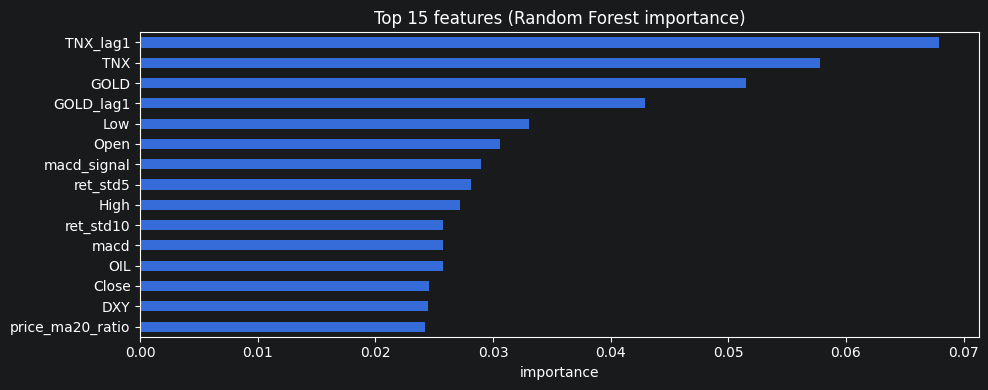


Top 5 features:
TNX_lag1     0.067879
TNX          0.057800
GOLD         0.051495
GOLD_lag1    0.042939
Low          0.033035
dtype: float64


In [31]:
rf = models["RandomForest"]
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15 = fi.tail(15)

plt.figure(figsize=(10, 4))
top15.plot(kind="barh")
plt.title("Top 15 features (Random Forest importance)")
plt.xlabel("importance")
plt.tight_layout(); plt.show()

print("\nTop 5 features:")
print(top15.tail(5).iloc[::-1])

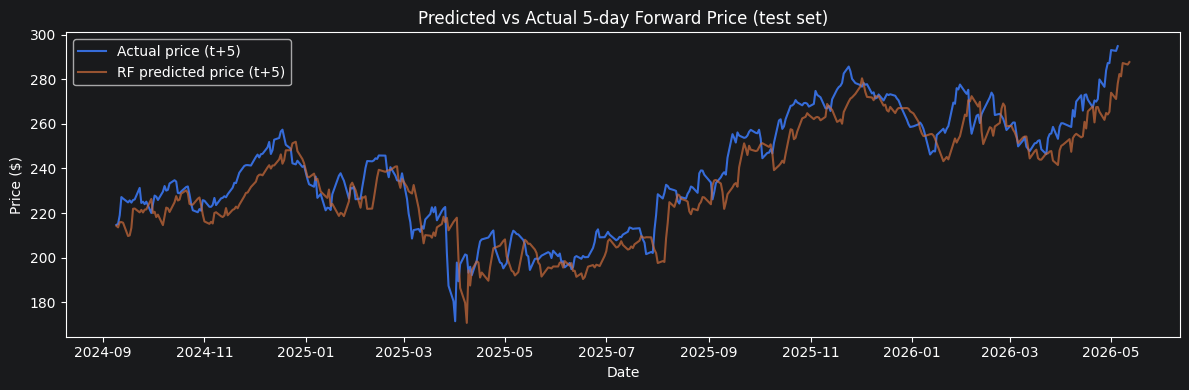

In [32]:
# realized 5-day-forward price = Close shifted -5
test_dates = X_test.index
realized_price  = feat_df.loc[test_dates, "Close"].shift(-5)
predicted_logret = models["RandomForest"].predict(X_test_scaled)
predicted_price  = feat_df.loc[test_dates, "Close"] * np.exp(predicted_logret)

plt.figure(figsize=(12, 4))
plt.plot(test_dates, realized_price,  label="Actual price (t+5)", linewidth=1.5)
plt.plot(test_dates, predicted_price, label="RF predicted price (t+5)", linewidth=1.5, alpha=0.7)
plt.title("Predicted vs Actual 5-day Forward Price (test set)")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.tight_layout(); plt.show()

# 8. Walk-forward Backtest

## run walk-forward

In [33]:
from src.forecast import walk_forward

wf = walk_forward(X, y, initial_train=1000, refit_every=21, horizon=5)
print("Walk-forward predictions:", len(wf))
print(wf.head())

Walk-forward predictions: 1793
              y_true    y_pred  fit_id
date                                  
2019-03-21 -0.033196  0.009016       0
2019-03-22 -0.005774  0.008834       0
2019-03-25  0.013159  0.007859       0
2019-03-26  0.037976  0.007599       0
2019-03-27  0.035854  0.007885       0


Total return:  +332.92%
Sharpe (ann.): 0.29
Max drawdown:  -96.32%
Num trades:    125
Win rate:      35.9%


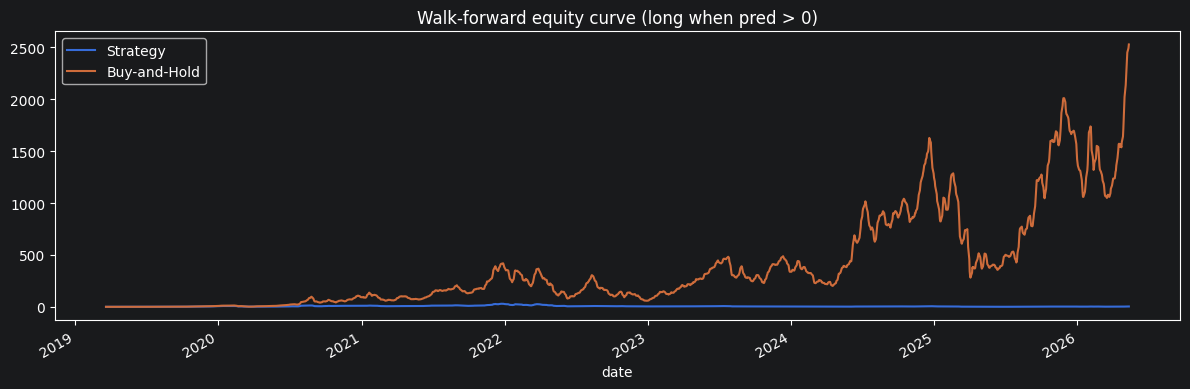

In [34]:
from src.forecast import backtest_strategy

result = backtest_strategy(wf, horizon=5)
print(f"Total return: {result['total_return']*100:+.2f}%")
print(f"Sharpe (ann.): {result['sharpe']:.2f}")
print(f"Max drawdown: {result['max_dd']*100:.2f}%")
print(f"Num trades: {result['num_trades']}")
print(f"Win rate: {result['win_rate']*100:.1f}%")

# equity curves
fig, ax = plt.subplots(figsize=(12, 4))
result["equity"].plot(ax=ax, label="Strategy")
(1 + result["bh_ret"]).cumprod().plot(ax=ax, label="Buy-and-Hold")
ax.set_title("Walk-forward equity curve (long when pred > 0)")
ax.legend(); plt.tight_layout(); plt.show()